In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [6]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


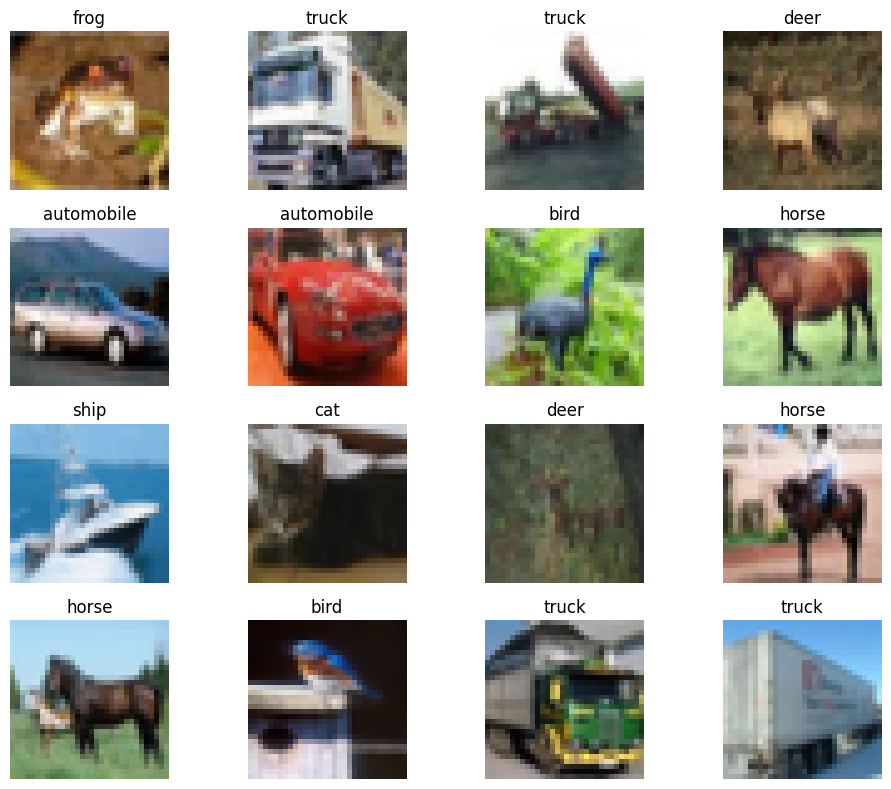

In [7]:
plt.figure(figsize=(10, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [9]:
x_val = x_train[45000:]
y_val = y_train[45000:]

x_train_new = x_train[:45000]
y_train_new = y_train[:45000]

print("Training:", x_train_new.shape)
print("Validation:", x_val.shape)
print("Testing:", x_test.shape)

Training: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Testing: (10000, 32, 32, 3)


In [10]:
model = keras.Sequential([
    
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [12]:
history = model.fit(
    x_train_new,
    y_train_new,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 70ms/step - accuracy: 0.3788 - loss: 1.6908 - val_accuracy: 0.5206 - val_loss: 1.3593
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.5374 - loss: 1.2944 - val_accuracy: 0.6106 - val_loss: 1.1066
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 84ms/step - accuracy: 0.6065 - loss: 1.1161 - val_accuracy: 0.6680 - val_loss: 0.9701
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.6511 - loss: 0.9970 - val_accuracy: 0.6976 - val_loss: 0.8689
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6821 - loss: 0.9125 - val_accuracy: 0.7226 - val_loss: 0.7954
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.7084 - loss: 0.8383 - val_accuracy: 0.7182 - val_loss: 0.8241
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.7279 - loss: 0.7789 - val_accuracy: 0.7468 - val_loss: 0.7311
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.7447 - loss: 0.7257 -

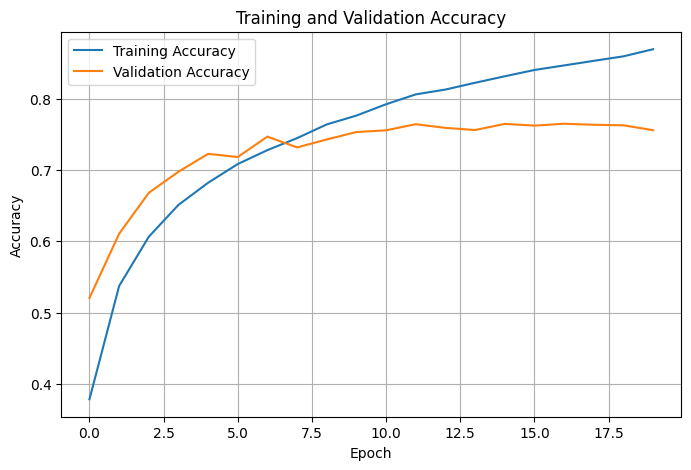

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

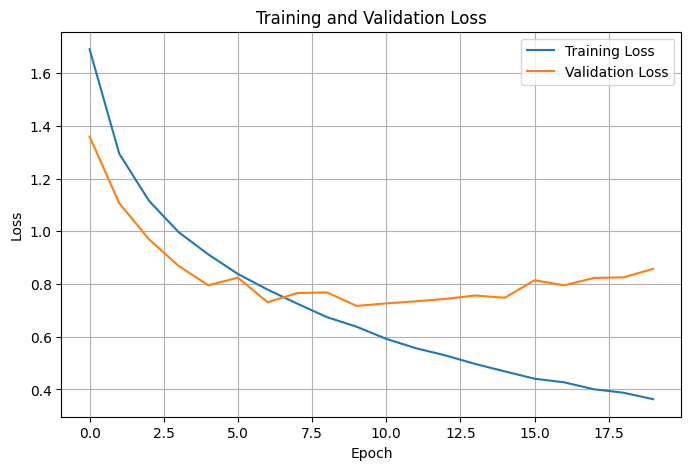

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7501 - loss: 0.8892
Test Loss: 0.8891751766204834
Test Accuracy: 0.7501000165939331


In [16]:
y_pred_probability = model.predict(x_test)

y_pred = np.argmax(y_pred_probability, axis=1)

y_true = y_test.flatten()

print("Actual:", y_true[:10])
print("Predicted:", y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
Actual: [3 8 8 0 6 6 1 6 3 1]
Predicted: [3 8 8 8 6 6 9 6 4 9]


In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.79      0.77      0.78      1000
  automobile       0.85      0.89      0.87      1000
        bird       0.62      0.68      0.65      1000
         cat       0.57      0.55      0.56      1000
        deer       0.64      0.79      0.71      1000
         dog       0.74      0.57      0.64      1000
        frog       0.77      0.83      0.80      1000
       horse       0.82      0.77      0.80      1000
        ship       0.89      0.83      0.86      1000
       truck       0.84      0.81      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



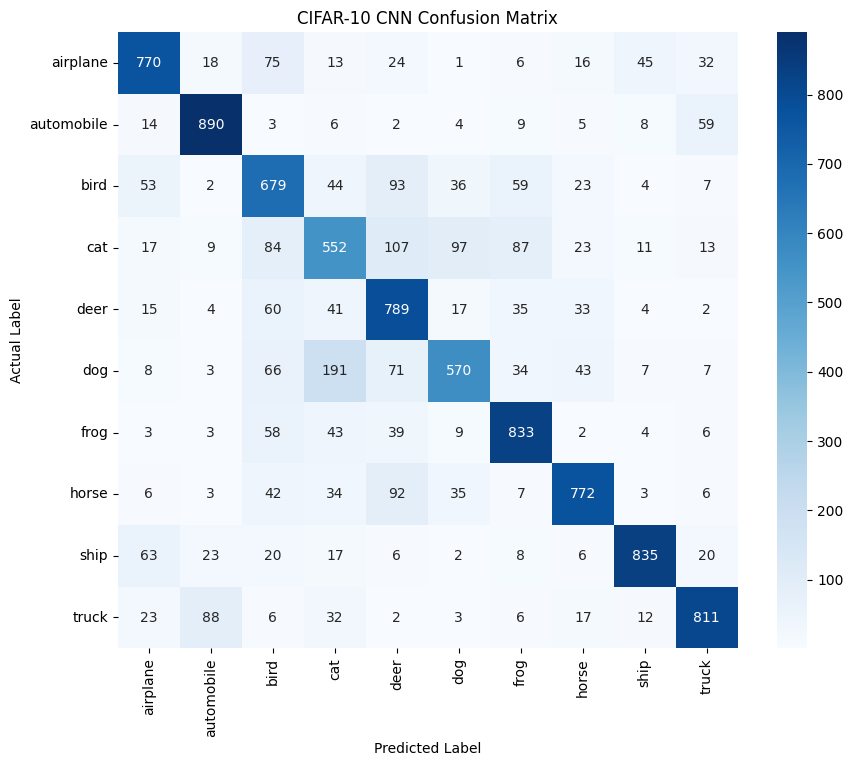

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('CIFAR-10 CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

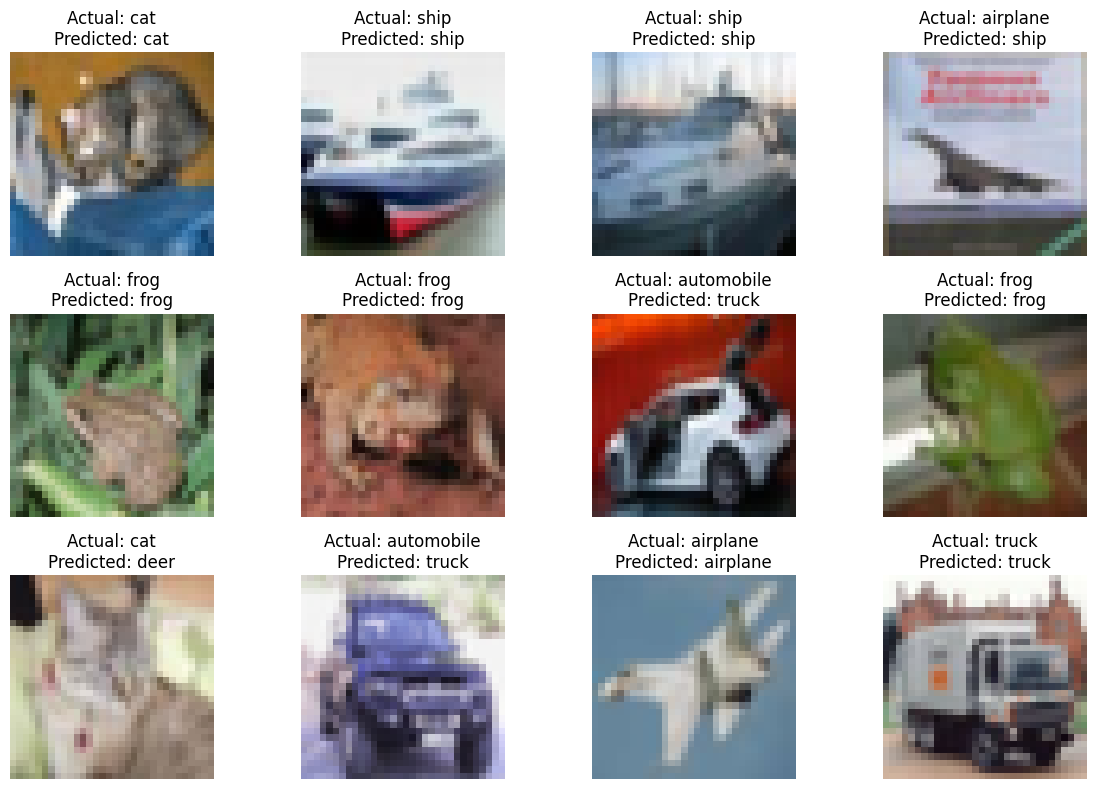

In [19]:
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
model.save("cifar10_cnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [21]:
loaded_model = keras.models.load_model("cifar10_cnn_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [22]:
loss, accuracy = loaded_model.evaluate(x_test, y_test, verbose=0)

print("Loaded Model Test Accuracy:", accuracy)

Loaded Model Test Accuracy: 0.7501000165939331


In [24]:
# Make predictions on test images
predictions = model.predict(x_test)

# Convert probabilities into class numbers
predicted_classes = np.argmax(predictions, axis=1)

# Convert actual labels into 1D array
actual_classes = y_test.flatten()

print("Predictions completed!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
Predictions completed!


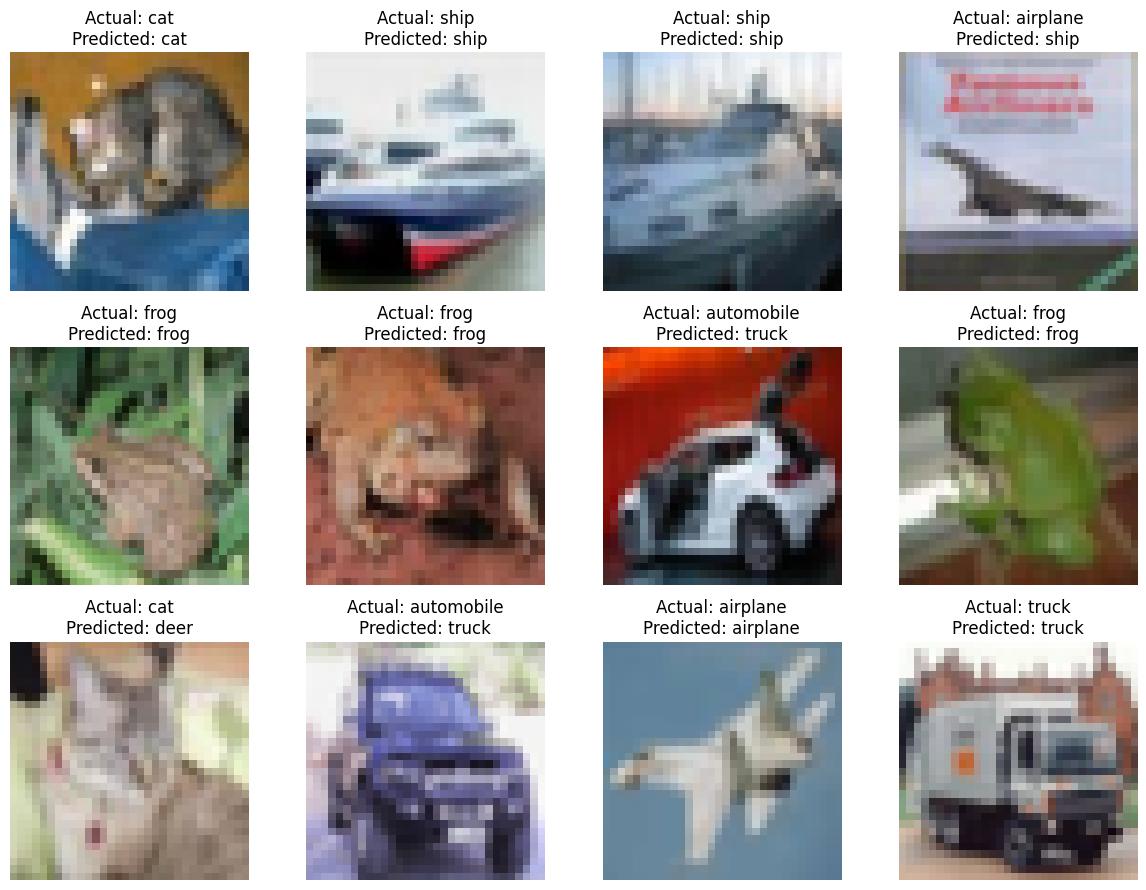

In [25]:
plt.figure(figsize=(12, 9))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # Display image
    plt.imshow(x_test[i])

    # Get actual and predicted class
    actual = class_names[actual_classes[i]]
    predicted = class_names[predicted_classes[i]]

    # Display result
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

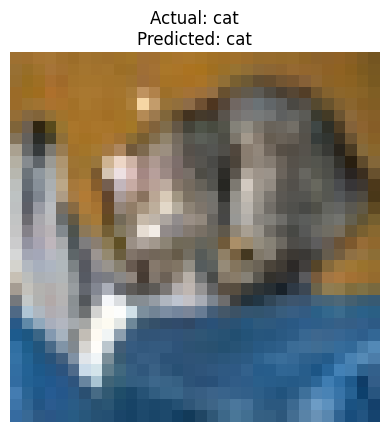

In [26]:
i = 0

plt.imshow(x_test[i])
plt.title(
    f"Actual: {class_names[actual_classes[i]]}\n"
    f"Predicted: {class_names[predicted_classes[i]]}"
)
plt.axis("off")
plt.show()

In [27]:
print("========== CNN MODEL RESULTS ==========")
print("Dataset       : CIFAR-10")
print("Model         : Convolutional Neural Network")
print("Training Data : 45,000 images")
print("Validation    : 5,000 images")
print("Testing Data  : 10,000 images")
print("---------------------------------------")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)
print("Accuracy (%)  :", test_accuracy * 100)
print("=======================================")

========== CNN MODEL RESULTS ==========
Dataset       : CIFAR-10
Model         : Convolutional Neural Network
Training Data : 45,000 images
Validation    : 5,000 images
Testing Data  : 10,000 images
---------------------------------------
Test Loss     : 0.8891751766204834
Test Accuracy : 0.7501000165939331
Accuracy (%)  : 75.01000165939331
